In [2]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd 
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


In [3]:
df = pd.read_excel('Tudo Gostoso_v2.xlsx', 
                   sheet_name='Books combined',nrows=84
)

carbon = pd.to_numeric(df['CF (gCO2e) total'], errors='coerce')
calories = pd.to_numeric(df['Calories (Kcal)'], errors='coerce')
protein = pd.to_numeric(df['Protein (g)'], errors='coerce')

In [4]:
type_cat = df['Type B'].astype('category')
type_a = type_cat.cat.codes

labels = type_cat.cat.categories
for i, label in enumerate(labels):
    print(i, label)

0 Beef
1 Pork
2 Poultry
3 Sea food 
4 Vegan
5 Vegetarian


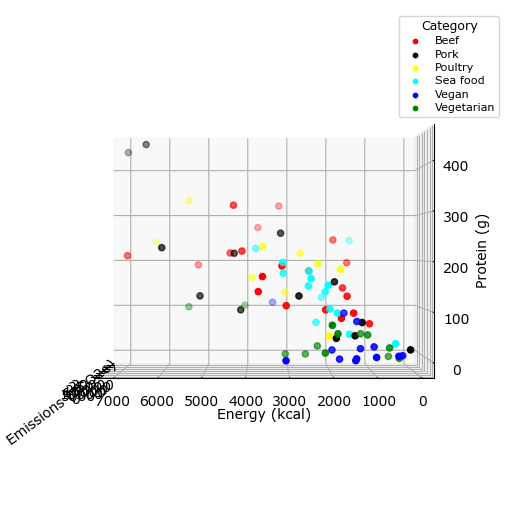

In [15]:
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')

colors = {
    'Beef': 'red',
    'Pork': 'black',
    'Poultry': 'yellow',
    'Vegetarian': 'green',
    'Vegan': 'blue',
    'Sea food ': 'cyan'
}

for category in df['Type B'].unique():
    mask = df['Type B'] == category
    ax.scatter(carbon[mask],
               calories[mask],
               protein[mask],
               color=colors[category],
               label=category)

ax.legend(    title="Category",
    fontsize=8,        # texto menor
    title_fontsize=9,  # título menor
    markerscale=0.7,   # diminui bolinhas
    labelspacing=0.3   # espaço entre itens)
)


ax.set_xlabel('Emissions (gCO2e)')
ax.set_ylabel('Energy (kcal)')
ax.set_zlabel('Protein (g)')

ax.view_init(elev=0, azim=180)
plt.tight_layout()
plt.subplots_adjust(right=0.85)

plt.show()